<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Tarea semanal 4
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

1) Obtener la función transferencia T(s) de Bessel para 
: 
, 
 y 
 normalizados para 
 utilizando el método de Storch: ver Schaumann, R. - Van Valkenburg, Mac E., Design of Analog Filters, Capítulo 10: Delay Filters. Sección 10.2: Bessel-Thomson Response. Página 403.

El filtro de retardo constante ideal esta dado por
$$
T(s)=\frac{1}{cosh(s)+senh(s)}
$$

para lograr la aproximacion de Bessel plateamos que:
$$
\frac{cosh(s)}{senh(s)}=\coth(s) =
\frac{1}{s}
+\cfrac{1}{\cfrac{3}{s}
+\cfrac{1}{\cfrac{5}{s}
+\cfrac{1}{\cfrac{7}{s}
+\cfrac{1}{\cfrac{9}{s}
+\ddots}}}}
$$

Si truncamos dicha expresion en algun termino vamos a poder encontrar el polinomio de Bessel de orden n.

#### Para n=2
$$
\frac{cosh(s)}{senh(s)}=\coth(s) =
\frac{1}{s}
+\cfrac{1}{\frac{3}{s}}= \frac{3+s^2}{3s}
$$

reemplazando esta aproximacion en $T(s)$
$$
T(s)=\frac{3}{s^2+3s+3}
$$

 **Nota:** El numerador se elige para que T(j0)=1

 #### Para n=3
$$
\frac{cosh(s)}{senh(s)}=\coth(s) =
\coth(s) =
\frac{1}{s}
+
\cfrac{1}{\cfrac{3}{s}+\cfrac{1}{\cfrac{5}{s}}} =
\frac{6s^2 + 15}{s^3+15s}
$$

reemplazando esta aproximacion en $T(s)$
$$
T(s)=\frac{15}{s^3+6s^2+15s+15}
$$

 **Nota:** El numerador se elige para que T(j0)=1

  #### Para n=4
Podemos aprovechar que ya conocemos $B_3$ y $B_2$ y calcularlo de forma recursiva recordando que:
$$
B_n=(2n-1)B_{n-1}+s^2B_{n-2}
$$
entonces:
$$
B_4=7B_{3}+s^2B_{2}=7(s^3+6s^2+15s+15)+s^2(s^2+3s+3)
$$
$$
B_4(s)=s^4+10s^3+45s^2+105s+105
$$

reemplazando esta aproximacion en $T(s)$
$$
T(s)=\frac{105}{s^4+10s^3+45s^2+105s+105}
$$

 **Nota:** El numerador se elige para que T(j0)=1

#### Requerimientos de la Plantilla
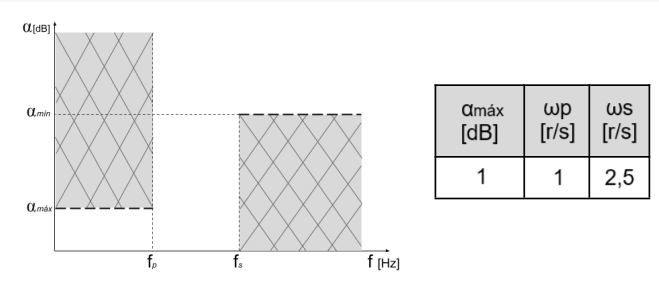

Veamos ahora que orden cumple con la plantilla

In [15]:
import sympy as sp
import numpy as np

s=sp.symbols('s')

B_2=s**2+3*s+3
B_3=s**3+6*s**2+15*s+15
B_4=7*B_3+(s**2)*B_2

T_2=B_2.subs(s,0)/B_2
T_3=B_3.subs(s,0)/B_3
T_4=B_4.subs(s,0)/B_4

print("|T_2(1)| dB =",20*np.log10(abs(complex(T_2.subs(s,1j)))))
print("|T_3(1)| dB =",20*np.log10(abs(complex(T_3.subs(s,1j)))))
print("|T_4(1)| dB =",20*np.log10(abs(complex(T_4.subs(s,1j)))))

|T_2(1)| dB = -1.5970084286751185
|T_3(1)| dB = -0.9029725095308612
|T_4(1)| dB = -0.6299531600397101


Podemos observar que n=3 es el minimo n que cumple con la condicion de $\alpha_{max}$

In [22]:
#Evaluar el retardo de grupo en D(w=2,5) y expresar en forma porcentual [%] el error o desviamiento respecto a D(w=0).

w = sp.symbols('w', real=True)
Tjw = T_3.subs(s, sp.I*w)
phi = sp.arg(Tjw)

D = -sp.diff(phi, w)

print((sp.N(D.subs(w,0))-sp.N(D.subs(w,2.5)))/(sp.N(D.subs(w,0)))*100)

24.7917493058310


#### Implementacion con sallen key
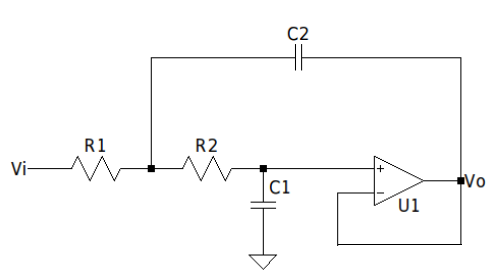

Recordemos la funcion transferencia:
$$
T(s) = \frac{\frac{G_1G_2}{C_1C_2}}{S^2+S[\frac{(G_1+G_2)}{C_2}]+\frac{G_2G_1}{C_2C_1}} 
$$

Para tener dos grados de libertad, tomamos $G_1=G_2$ y normalizamos con $\Omega_z=G_1$ y $\Omega_\omega=\sqrt{\frac{G_1G_2}{C_1C_2}}$. Entonces:
$$
C_1C_2=1 
$$
$$
2Q=C_2
$$

Analicemos ahora la trasferencia que queremos lograr:
$$
T(s)=\frac{15}{s^3+6s^2+15s+15}
$$
Separando en SOS:
$$
T(s)=\frac{2.322}{s+2.322}\frac{6.46}{s^2+3.678s+6.46}
$$

El SOS que queremos implementar tiene:
$$
\omega_0=2.541
$$
$$
Q=0.69
$$

entonces:
$$
C_2=1.381
$$
$$
C_1=0.724
$$

desnormalizando para obtener $\omega_0=2.541$:
$$
C_2=0.543
$$
$$
C_1=0.285
$$

Queremos ahora que el retardo sea $D=200us$, entonces $\Omega_w=1/200us=5000$. Los componentes quedan:
$$
C_2=\frac{0.543}{\Omega_w}=108.6uF
$$
$$
C_1=\frac{0.285}{\Omega_w}=57uF
$$

#### Simulacion en LTspice
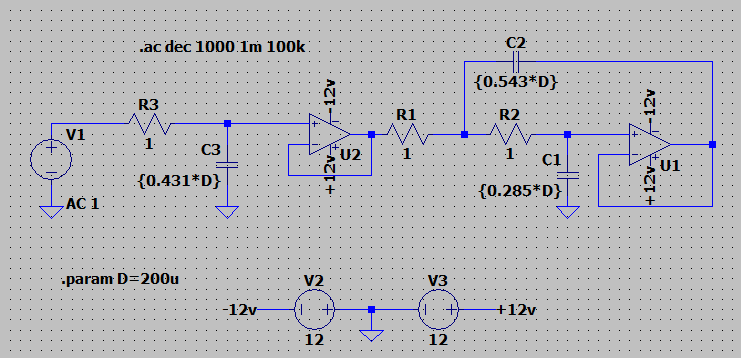

La transferencia queda:

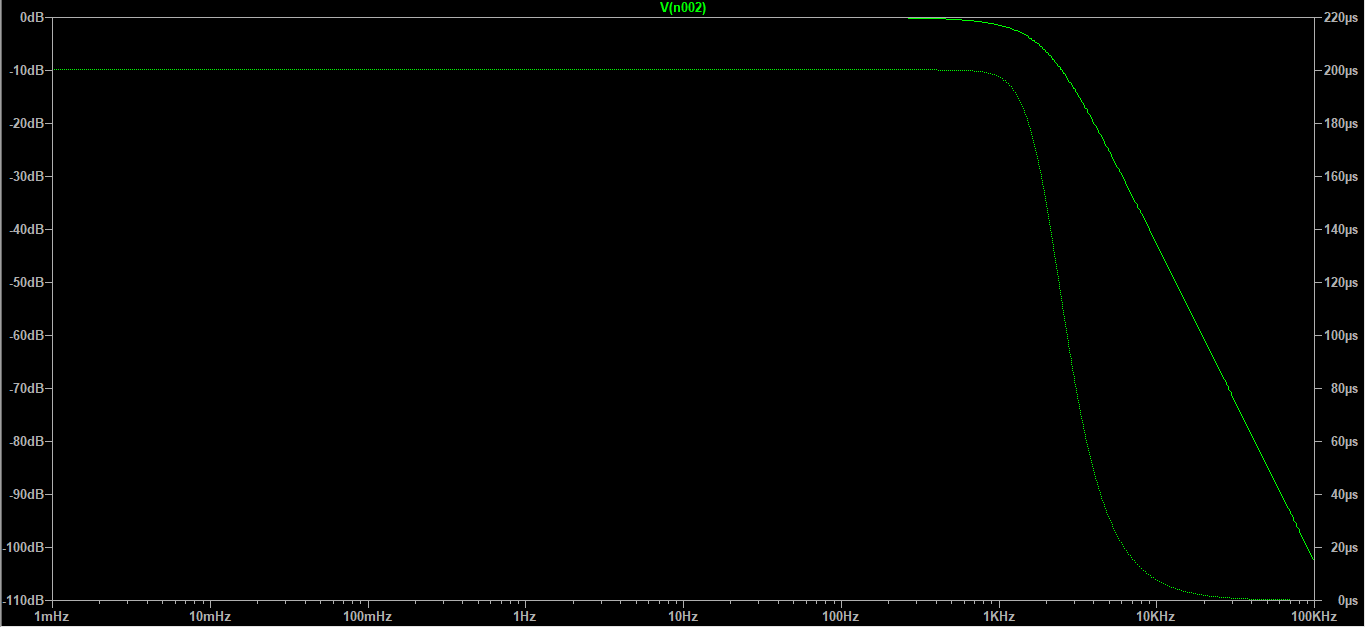

Se aprecia la planitud del retardo de grupo en la banda de paso, confirmando el comportamiento 
esperado de un filtro Bessel. La atenuación en $\Omega = 1$ rad/s verifica el cumplimiento de la 
plantilla.

### Conclusión

Se determinó que el orden mínimo que cumple con la restricción de atenuación máxima $\alpha_{max}$ en $\Omega = 1$ rad/s es $n = 3$, ya que los órdenes inferiores exceden la atenuación requerida por la plantilla.

El error del retardo de grupo evaluado en $\omega = 2.5$ rad/s respecto al retardo en DC $D(\omega=0)$ es de $24.8\%$.

Finalmente, la implementación mediante topología Sallen-Key con los valores de componentes obtenidos — $C_1 = 57\,\mu\text{F}$, $C_2 = 108.6\,\mu\text{F}$ para el SOS y $C_3 = 86.2\,\mu\text{F}$ para la sección de primer orden, con $R = 1\,\Omega$ — fue verificada mediante simulación en LTspice, obteniéndose una respuesta en frecuencia consistente con la función transferencia teórica de Bessel de orden 3 escalada a $D(0) = 200\,\mu\text{s}$.



